# LangGraph Tool Chatbot: Currency Conversion

This notebook builds a small LangGraph chatbot that can call a custom currency conversion tool. It focuses on the core tool-calling pattern: message state with `Annotated` and `add_messages`, a `ToolNode`, and conditional routing with `tools_condition`.

The graph does not use checkpointing. Each invocation starts from the messages you pass into the graph.

## Environment setup

Load credentials from `.env` and require `GROQ_API_KEY`. The tutorial uses Groq as the only model provider so the tool-calling graph stays compact.

In [1]:
import os
import sys
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Markdown, display
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

assert os.getenv("GROQ_API_KEY"), "Add GROQ_API_KEY to your .env file."

print(f"Python executable: {sys.executable}")

/Users/mlstudio/Claude-Code/ml-lab-new/tutorial-agentic-ai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python executable: /Users/mlstudio/Claude-Code/ml-lab-new/tutorial-agentic-ai/.venv/bin/python


## Define demo conversion rates and the tool

The tool uses fixed tutorial rates. These values make the notebook reproducible, but they are not live financial data and should not be used for trading, accounting, or real purchases.

In [2]:
DEMO_USD_RATES = {
    "EUR": 0.92,
    "GBP": 0.79,
    "JPY": 151.30,
    "CAD": 1.36,
    "AUD": 1.52,
    "USD": 1.00,
}


@tool
def convert_usd(amount: float, target_currency: str) -> str:
    """Convert a US dollar amount using fixed demo rates, or keep it as USD."""
    currency = target_currency.upper()
    if currency not in DEMO_USD_RATES:
        supported = ", ".join(sorted(DEMO_USD_RATES))
        return f"Unsupported currency '{target_currency}'. Supported currencies: {supported}."
    if currency == "USD":
        return f"{amount:,.2f} USD remains {amount:,.2f} USD; no conversion is needed."

    converted_amount = amount * DEMO_USD_RATES[currency]
    return (
        f"{amount:,.2f} USD is approximately {converted_amount:,.2f} {currency} "
        f"using the fixed tutorial rate 1 USD = {DEMO_USD_RATES[currency]} {currency}."
    )


tools = [convert_usd]
print(convert_usd.name)
print(convert_usd.description)

convert_usd
Convert a US dollar amount using fixed demo rates, or keep it as USD.


## Define LangGraph message state

`Annotated` keeps the field type as `list[BaseMessage]` while attaching LangGraph merge behavior. The `add_messages` reducer appends or merges new messages returned by graph nodes instead of replacing the full conversation list.

In [3]:
class ChatbotState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

## Build the no-checkpoint tool-calling graph

Bind the conversion tool to the model, wrap tool execution in `ToolNode`, and use `tools_condition` to route assistant tool calls to the tool node. When the model does not request a tool, the graph ends.

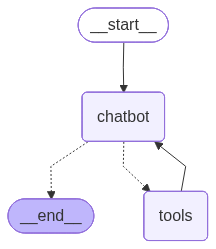

In [4]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
).bind_tools(tools)


def call_chatbot(state: ChatbotState) -> ChatbotState:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(ChatbotState)
builder.add_node("chatbot", call_chatbot)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")

currency_chatbot = builder.compile()
currency_chatbot

## Invoke the chatbot

Use a reproducible prompt that asks for a USD conversion. The system message tells the assistant to use the tool for conversion questions and then summarize the tool result.

In [5]:
result = currency_chatbot.invoke(
    {
        "messages": [
            SystemMessage(
                content=(
                    "You are a concise currency assistant. Call convert_usd when converting "
                    "USD to a supported non-USD target currency. Leave USD amounts as USD. "
                    "After the tool returns, answer with the converted amount and mention "
                    "that the rate is a fixed demo value."
                )
            ),
            HumanMessage(content="Convert 125 USD to JPY. Use the tool."),
        ]
    }
)

print(f"Messages in final state: {len(result['messages'])}")
display(Markdown(result["messages"][-1].content))

Messages in final state: 5


The converted amount is 18,912.50 JPY. Please note that the rate used is a fixed demo value.

## Inspect tool calls and tool results

The first assistant response should contain an `AIMessage.tool_calls` entry. `ToolNode` executes that request and appends a `ToolMessage` with the conversion result before routing back to the chatbot for the final answer.

In [6]:
tool_call_messages = [
    message
    for message in result["messages"]
    if isinstance(message, AIMessage) and message.tool_calls
]
tool_messages = [
    message
    for message in result["messages"]
    if isinstance(message, ToolMessage)
]

assert tool_call_messages, "Expected the assistant to request a tool call."
assert tool_messages, "Expected ToolNode to append a ToolMessage result."

first_tool_call = tool_call_messages[0].tool_calls[0]
first_tool_result = tool_messages[0]

print("Tool call requested by AIMessage:")
print(first_tool_call)
print("\nToolMessage returned by ToolNode:")
print(first_tool_result.content)
print("\nFinal assistant response:")
print(result["messages"][-1].content)

Tool call requested by AIMessage:
{'name': 'convert_usd', 'args': {'amount': 125, 'target_currency': 'JPY'}, 'id': 'e4ksqxv7p', 'type': 'tool_call'}

ToolMessage returned by ToolNode:
125.00 USD is approximately 18,912.50 JPY using the fixed tutorial rate 1 USD = 151.3 JPY.

Final assistant response:
The converted amount is 18,912.50 JPY. Please note that the rate used is a fixed demo value.


## Add a chat loop

Because this graph has no checkpointing, the loop owns the conversation history. Each turn sends the existing messages plus the new user message into the graph, then stores the final state returned by LangGraph.

In [7]:
EXIT_COMMANDS = {"exit", "quit", "q", ":q", "bye"}
CURRENCY_SYSTEM_PROMPT = (
    "You are a concise currency assistant. Call convert_usd when converting USD to "
    "a supported non-USD target currency. Leave USD amounts as USD. After the tool "
    "returns, answer with the converted amount and mention that the rate is a fixed "
    "demo value."
)


def should_exit(user_text: str) -> bool:
    return user_text.strip().lower() in EXIT_COMMANDS


def ask_currency_chatbot(
    messages: list[BaseMessage],
    user_text: str,
) -> list[BaseMessage]:
    result = currency_chatbot.invoke(
        {"messages": [*messages, HumanMessage(content=user_text)]}
    )
    return result["messages"]


def currency_chat_loop() -> None:
    messages: list[BaseMessage] = [SystemMessage(content=CURRENCY_SYSTEM_PROMPT)]

    while True:
        user_text = input("You: ")
        if should_exit(user_text):
            print("Assistant: Ending the currency chat loop.")
            break

        messages = ask_currency_chatbot(messages, user_text)
        print(f"Assistant: {messages[-1].content}\n")


# Uncomment the next line in Jupyter to start a live chat session.
# currency_chat_loop()

Run the same loop logic with scripted inputs so the notebook can execute from top to bottom without waiting for keyboard input.

In [8]:
conversation = [SystemMessage(content=CURRENCY_SYSTEM_PROMPT)]
scripted_user_inputs = [
    "Convert 50 USD to EUR.",
    "Now convert 20 USD to GBP.",
    "quit",
]

for user_text in scripted_user_inputs:
    print(f"User: {user_text}")
    if should_exit(user_text):
        print("Assistant: Ending the currency chat loop.")
        break

    conversation = ask_currency_chatbot(conversation, user_text)
    print(f"Assistant: {conversation[-1].content}\n")

print(f"Messages kept in loop history: {len(conversation)}")

User: Convert 50 USD to EUR.
Assistant: The converted amount is 46.00 EUR. Please note that the rate used for this conversion is a fixed demo value.

User: Now convert 20 USD to GBP.
Assistant: The converted amount is 15.80 GBP. Please note that the rate used for this conversion is a fixed demo value.

User: quit
Assistant: Ending the currency chat loop.
Messages kept in loop history: 9


## Inspect every message in one loop session

A LangGraph run returns the complete message sequence for that turn. In the no-checkpoint chat loop, keep that returned list and inspect each message object in order.

In [9]:
def print_message_sequence(messages: list[BaseMessage]) -> None:
    for index, message in enumerate(messages, start=1):
        message_type = type(message).__name__
        print(f"{index}. {message_type}")

        if isinstance(message, AIMessage) and message.tool_calls:
            print("   tool_calls:")
            for tool_call in message.tool_calls:
                print(f"   - name: {tool_call['name']}")
                print(f"     args: {tool_call['args']}")
                print(f"     id: {tool_call['id']}")

        if isinstance(message, ToolMessage):
            print(f"   tool_call_id: {message.tool_call_id}")
            print(f"   tool_name: {message.name}")

        if message.content:
            print(f"   content: {message.content}")
        print()


single_session_messages = [SystemMessage(content=CURRENCY_SYSTEM_PROMPT)]
single_session_messages = ask_currency_chatbot(
    single_session_messages,
    "I have $200, I want to convert half to EUR and other half to CAD. "
    "How much EUR and CAD I will have?",
)

print_message_sequence(single_session_messages)

1. SystemMessage
   content: You are a concise currency assistant. Call convert_usd when converting USD to a supported non-USD target currency. Leave USD amounts as USD. After the tool returns, answer with the converted amount and mention that the rate is a fixed demo value.

2. HumanMessage
   content: I have $200, I want to convert half to EUR and other half to CAD. How much EUR and CAD I will have?

3. AIMessage
   tool_calls:
   - name: convert_usd
     args: {'amount': 100, 'target_currency': 'EUR'}
     id: szprdkpyf
   - name: convert_usd
     args: {'amount': 100, 'target_currency': 'CAD'}
     id: nwk4tygyt

4. ToolMessage
   tool_call_id: szprdkpyf
   tool_name: convert_usd
   content: 100.00 USD is approximately 92.00 EUR using the fixed tutorial rate 1 USD = 0.92 EUR.

5. ToolMessage
   tool_call_id: nwk4tygyt
   tool_name: convert_usd
   content: 100.00 USD is approximately 136.00 CAD using the fixed tutorial rate 1 USD = 1.36 CAD.

6. AIMessage
   content: You will have a

## Key takeaways

This graph keeps the state definition small while still supporting tool calls. `add_messages` controls how each node's message updates are merged, `tools_condition` decides whether the assistant requested a tool, and `ToolNode` executes the selected tool before sending the tool result back to the model. The chat loop keeps history explicitly in Python because this notebook does not use checkpointing.

The exchange rates in this notebook are fixed tutorial values, not live financial data.